In [43]:
import pandas as pd # For data manipulation and analysis
import numpy as np # For numerical operations
import matplotlib.pyplot as plt # For creating static, animated, and interactive visualizations
import seaborn as sns # For statistical data visualization
import joblib # For saving and loading models

# For Machine Learning
from sklearn.model_selection import train_test_split # For splitting data into training and testing sets
from sklearn.linear_model import LinearRegression, LogisticRegression # A common linear model for regression tasks, and for classification
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix # Metrics for evaluating regression models and classification models
from sklearn.ensemble import RandomForestClassifier # For Random Forest models

# Uncomment the following lines to install if you haven't already
# !pip install pandas numpy matplotlib seaborn scikit-learn

print("Common ML and Data Science libraries imported successfully!")

Common ML and Data Science libraries imported successfully!


In [2]:
import kagglehub
path = kagglehub.dataset_download("rxshark/uci-student-performance-dataset-by-paulo-cortez")

100%|██████████| 7.85k/7.85k [00:00<00:00, 12.8MB/s]

Extracting files...


In [5]:
import os

# Construct the full path to the student-mat.csv file
csv_file_path = os.path.join(path, 'student-mat.csv')

# Load the CSV file into a pandas DataFrame, specifying semicolon as delimiter
df = pd.read_csv(csv_file_path, delimiter=';')

# Display the first 5 rows of the DataFrame
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [7]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [8]:
df.shape

(395, 33)

In [9]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## Missing Values Check
Let's check if there are any missing values in our dataset.

In [10]:
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")

Missing values in each column:
Series([], dtype: int64)
No missing values found in the dataset.


In [11]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows == 0:
    print("No duplicate rows found in the dataset.")
else:
    print("Consider removing duplicate rows if they are not intentional.")

Number of duplicate rows: 0
No duplicate rows found in the dataset.


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [13]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


**Exploratory Data Analysis (EDA)**

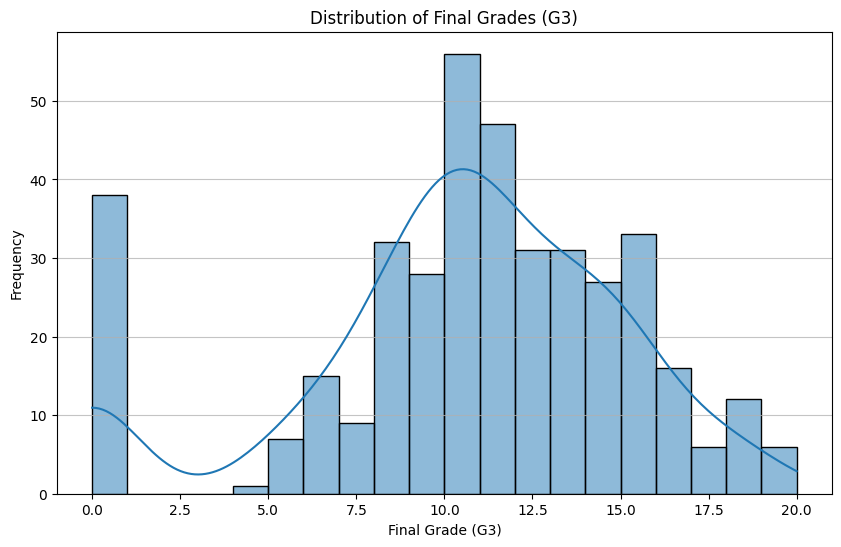

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df['G3'], bins=20, kde=True)
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [15]:
correlation_matrix = df[['G1', 'G2', 'G3']].corr()
print(correlation_matrix)

          G1        G2        G3
G1  1.000000  0.852118  0.801468
G2  0.852118  1.000000  0.904868
G3  0.801468  0.904868  1.000000


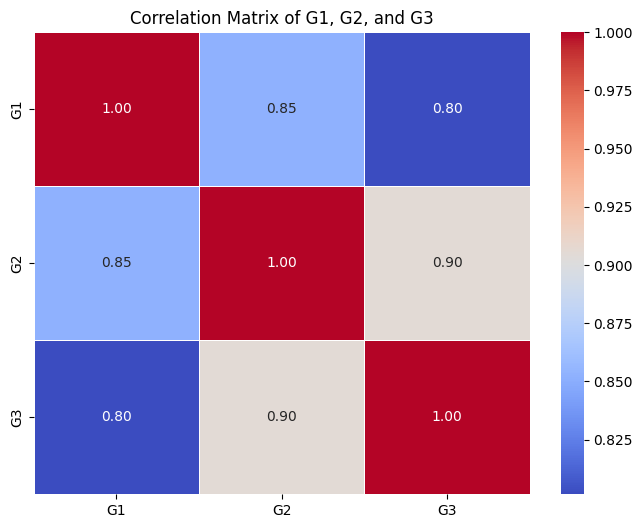

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of G1, G2, and G3')
plt.show()

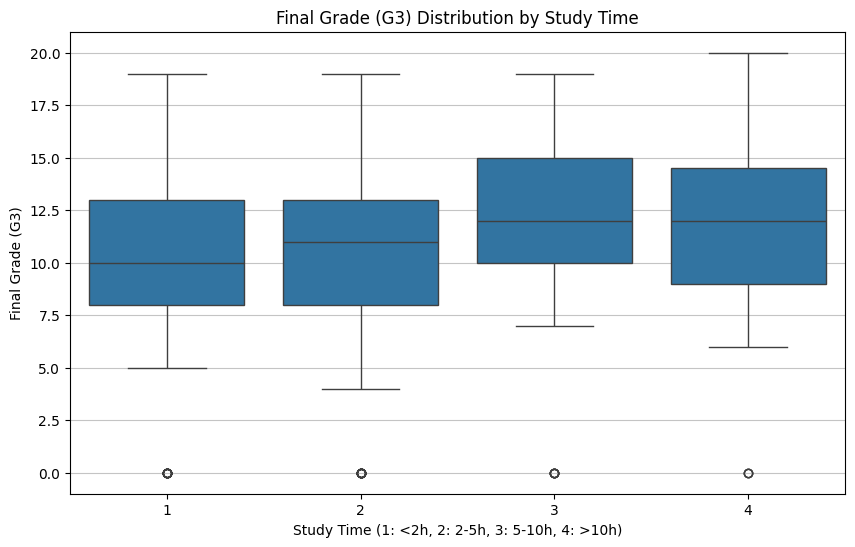

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='studytime', y='G3', data=df)
plt.title('Final Grade (G3) Distribution by Study Time')
plt.xlabel('Study Time (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h)')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', alpha=0.75)
plt.show()

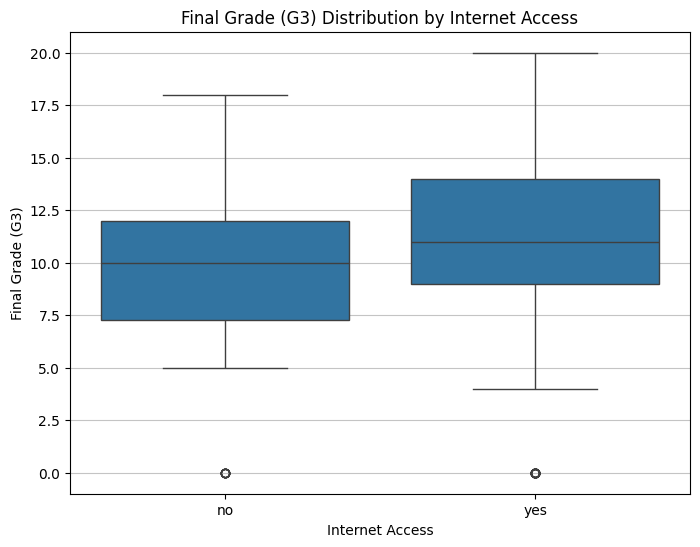

In [18]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='internet', y='G3', data=df)
plt.title('Final Grade (G3) Distribution by Internet Access')
plt.xlabel('Internet Access')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', alpha=0.75)
plt.show()

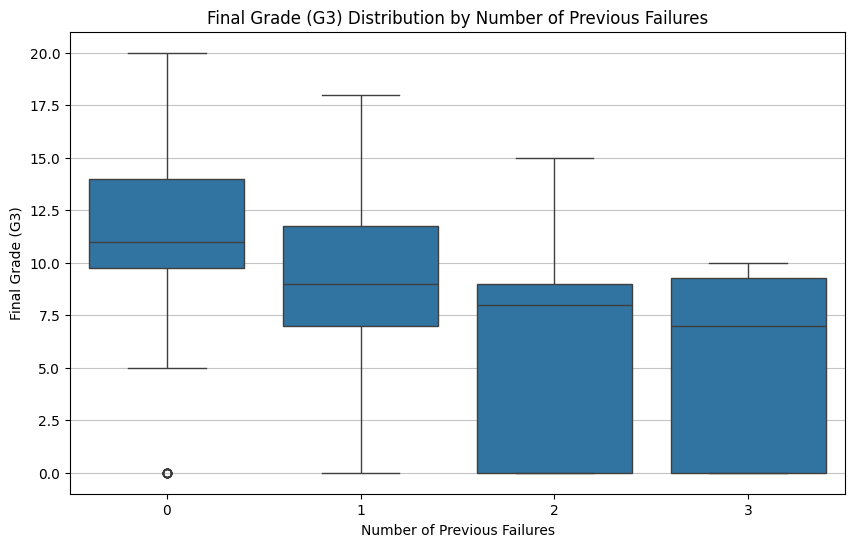

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='failures', y='G3', data=df)
plt.title('Final Grade (G3) Distribution by Number of Previous Failures')
plt.xlabel('Number of Previous Failures')
plt.ylabel('Final Grade (G3)')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Correlation Heatmap of All Numerical Features

Let's visualize the correlation matrix of all numerical columns in the dataset to identify potential relationships between different student attributes and grades.

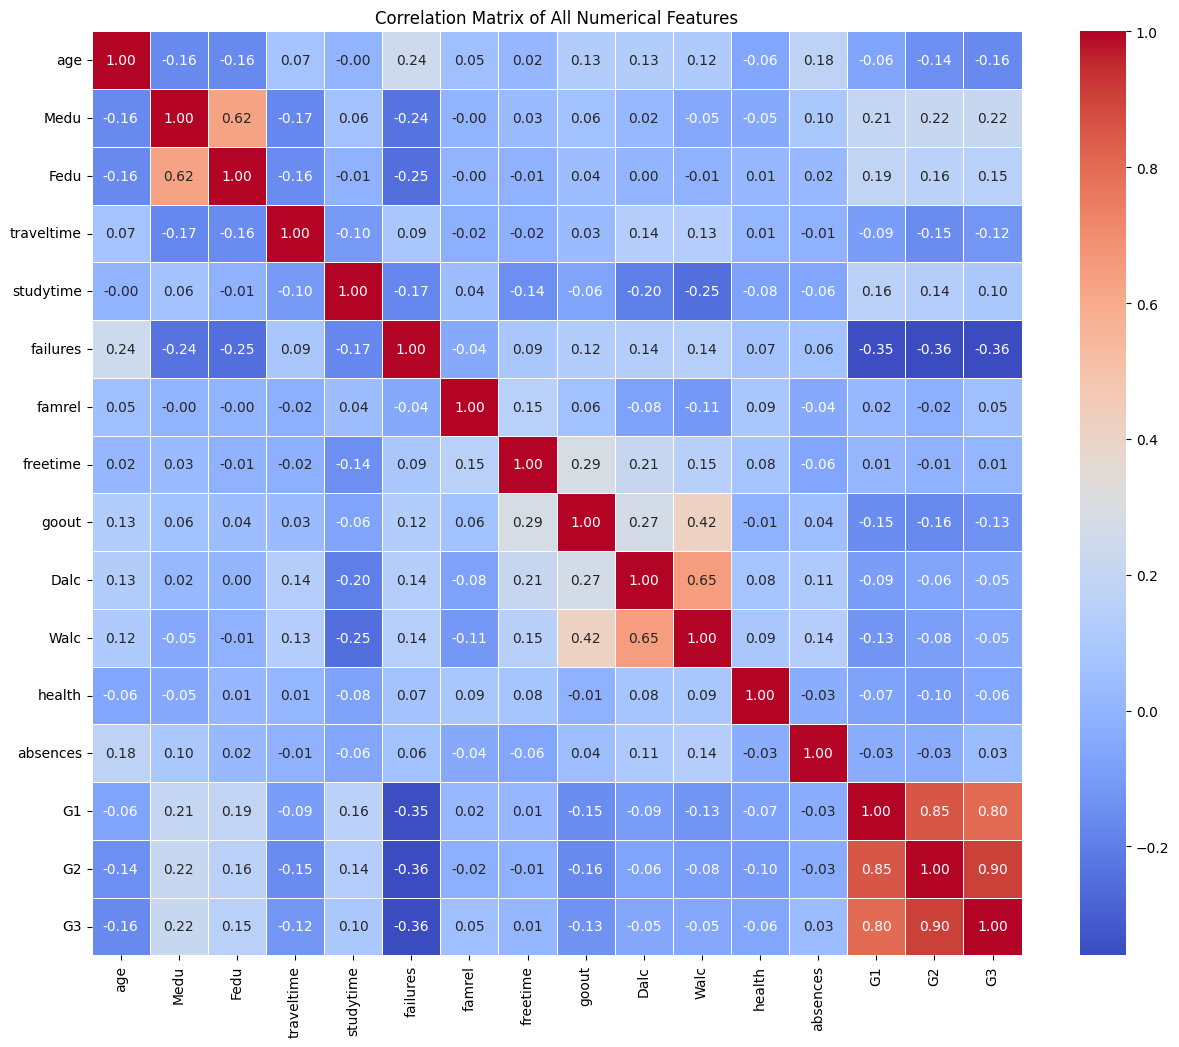

In [20]:
numerical_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(15, 12))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of All Numerical Features')
plt.show()

In [21]:
print("Original DataFrame shape:", df.shape)

# Identify categorical columns (object dtype)
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame shape after one-hot encoding:", df_encoded.shape)
print("First 5 rows of the encoded DataFrame:")
print(df_encoded.head())

Original DataFrame shape: (395, 33)
DataFrame shape after one-hot encoding: (395, 42)
First 5 rows of the encoded DataFrame:
   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         3       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  guardian_mother  guardian_other  schoolsup_yes  famsup_yes  \
0     1  ...             True           False           True       False   
1     1  ...            False           False          False        True   
2     2  ...             True           False           True       False   
3     1  ...             True           False          False        True   
4     1  ...  

In [27]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [23]:
# Identify binary categorical columns from the original DataFrame 'df'
binary_cols = [col for col in df.select_dtypes(include='object').columns if df[col].nunique() == 2]

# Create a copy of the original DataFrame to apply binary encoding
df_binary_encoded = df.copy()

# Apply mapping for binary columns (e.g., 'yes'/'no' to 1/0, or other boolean values)
for col in binary_cols:
    unique_vals = df[col].unique()
    # Assuming the first unique value is considered 'false' and the second 'true'
    # This needs careful consideration based on actual data, but is a common pattern
    if len(unique_vals) == 2:
        mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
        # Check for common 'yes'/'no' patterns if a specific mapping is desired
        if 'yes' in unique_vals and 'no' in unique_vals:
            mapping = {'no': 0, 'yes': 1}
        df_binary_encoded[col] = df_binary_encoded[col].map(mapping)

print("Original binary columns and their unique values before encoding:")
for col in binary_cols:
    print(f"{col}: {df[col].unique()}")

print("\nFirst 5 rows of DataFrame with binary variables explicitly encoded:")
print(df_binary_encoded[binary_cols].head())

Original binary columns and their unique values before encoding:
school: ['GP' 'MS']
sex: ['F' 'M']
address: ['U' 'R']
famsize: ['GT3' 'LE3']
Pstatus: ['A' 'T']
schoolsup: ['yes' 'no']
famsup: ['no' 'yes']
paid: ['no' 'yes']
activities: ['no' 'yes']
nursery: ['yes' 'no']
higher: ['yes' 'no']
internet: ['no' 'yes']
romantic: ['no' 'yes']

First 5 rows of DataFrame with binary variables explicitly encoded:
   school  sex  address  famsize  Pstatus  schoolsup  famsup  paid  \
0       0    0        0        0        0          1       0     0   
1       0    0        0        0        1          0       1     0   
2       0    0        0        1        1          1       0     1   
3       0    0        0        0        1          0       1     1   
4       0    0        0        0        1          0       1     1   

   activities  nursery  higher  internet  romantic  
0           0        1       1         0         0  
1           0        0       1         1         0  
2           

In [32]:
print("Correlations of features with G3 (Final Grade):\n")

# Calculate correlations with G3 using the encoded DataFrame
correlations_with_G3 = df_encoded.corr()['G3'].sort_values(ascending=False)

# Display the correlations
print(correlations_with_G3)

# You might consider features with a correlation magnitude above a certain threshold for your model.

Correlations of features with G3 (Final Grade):

G3                   1.000000
G2                   0.904868
G1                   0.801468
Medu                 0.217147
higher_yes           0.182465
Fedu                 0.152457
Mjob_health          0.116158
address_U            0.105756
sex_M                0.103456
paid_yes             0.101996
internet_yes         0.098483
studytime            0.097820
reason_reputation    0.095692
Fjob_teacher         0.095374
famsize_LE3          0.081407
Mjob_services        0.078429
Mjob_teacher         0.057712
Fjob_health          0.057111
reason_other         0.052008
nursery_yes          0.051568
famrel               0.051363
absences             0.034247
guardian_mother      0.022338
activities_yes       0.016100
freetime             0.011307
Fjob_services       -0.016108
reason_home         -0.021359
famsup_yes          -0.039157
school_MS           -0.045017
Walc                -0.051939
Fjob_other          -0.053483
Dalc                -

In [29]:
X = df_encoded.drop('G3', axis=1)
y = df_encoded['G3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (316, 41)
Testing features shape: (79, 41)
Training target shape: (316,)
Testing target shape: (79,)


In [30]:
output_file_path = 'student_data_cleaned.csv'
df_encoded.to_csv(output_file_path, index=False)
print(f"Cleaned data exported successfully to '{output_file_path}'")

Cleaned data exported successfully to 'student_data_cleaned.csv'


In [33]:
python_code_to_export = """import pandas as pd
import os

def preprocess_student_data(csv_path):
    \"\"\"
    Loads student data from a CSV, performs one-hot encoding on categorical
    features, and returns the encoded DataFrame.
    \"\"\"
    try:
        df = pd.read_csv(csv_path, delimiter=';')
    except FileNotFoundError:
        print(f"Error: The file at {csv_path} was not found.")
        print("Please ensure 'student-mat.csv' is in the specified path or adjust the path.")
        return None

    categorical_cols = df.select_dtypes(include=['object']).columns
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    return df_encoded

if __name__ == "__main__":
    # NOTE: This path might need to be adjusted based on where you run this script
    # and where the 'student-mat.csv' file is located.
    # In this Colab environment, it was downloaded to:
    # '/root/.cache/kagglehub/datasets/rxshark/uci-student-performance-dataset-by-paulo-cortez/versions/1/student-mat.csv'
    # For local execution, you might place 'student-mat.csv' in the same directory
    # as this script, or specify its full path.
    data_file_path = '/root/.cache/kagglehub/datasets/rxshark/uci-student-performance-dataset-by-paulo-cortez/versions/1/student-mat.csv'


    print(f"Attempting to preprocess data from: {data_file_path}")
    encoded_df = preprocess_student_data(data_file_path)

    if encoded_df is not None:
        print("\nPreprocessing successful. First 5 rows of the encoded DataFrame:")
        print(encoded_df.head())
        # Optionally, save the processed data to a new CSV file
        # output_csv_path = 'student_data_preprocessed_from_script.csv'
        # encoded_df.to_csv(output_csv_path, index=False)
        # print(f"Encoded data saved to {output_csv_path}")
    else:
        print("Preprocessing failed.")"""

file_name = "preprocess_data.py"
with open(file_name, "w") as f:
    f.write(python_code_to_export)

print(f"Python preprocessing script '{file_name}' created successfully.")

Python preprocessing script 'preprocess_data.py' created successfully.


**Model Training**

In [36]:
# For Logistic Regression, we need a binary target variable.
# Let's define 'pass' as G3 >= 10 and 'fail' as G3 < 10.
y_train_binary = (y_train >= 10).astype(int)
y_test_binary = (y_test >= 10).astype(int)

# Initialize the Logistic Regression model
logistic_model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for small datasets

# Fit the model on the training data
logistic_model.fit(X_train, y_train_binary)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


Model Accuracy: 0.92

Confusion Matrix:
[[25  2]
 [ 4 48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89        27
           1       0.96      0.92      0.94        52

    accuracy                           0.92        79
   macro avg       0.91      0.92      0.92        79
weighted avg       0.93      0.92      0.92        79



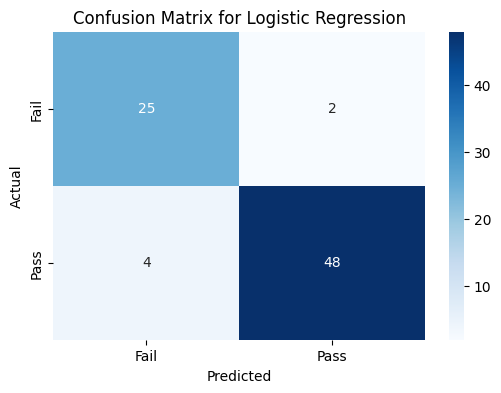

In [38]:
# Make predictions on the test set
y_pred_binary = logistic_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test_binary, y_pred_binary)
conf_matrix = confusion_matrix(y_test_binary, y_pred_binary)
class_report = classification_report(y_test_binary, y_pred_binary)

print(f"Model Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# You can also visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [ ]:
## Model Evaluation Summary

### Logistic Regression Model

**Accuracy:** 0.92

**Confusion Matrix:**
```
[[25  2]
 [ 4 48]]
```

**Classification Report:**
```
              precision    recall  f1-score   support

           0       0.86      0.93      0.89        27
           1       0.96      0.92      0.94        52

    accuracy                           0.92        79
   macro avg       0.91      0.92      0.92        79
weighted avg       0.93      0.92      0.92        79
```

### Random Forest Classifier Model

**Accuracy:** 0.92

**Confusion Matrix:**
```
[[26  1]
 [ 5 47]]
```

**Classification Report:**
```
              precision    recall  f1-score   support

           0       0.84      0.96      0.90        27
           1       0.98      0.90      0.94        52

    accuracy                           0.92        79
   macro avg       0.91      0.93      0.92        79
weighted avg       0.93      0.92      0.93        79
```

In [40]:
# Initialize the Random Forest Classifier
# Using a random_state for reproducibility
random_forest_model = RandomForestClassifier(random_state=42)

# Fit the model to the training data
random_forest_model.fit(X_train, y_train_binary)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


Random Forest Model Accuracy: 0.92

Random Forest Confusion Matrix:
[[26  1]
 [ 5 47]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.96      0.90        27
           1       0.98      0.90      0.94        52

    accuracy                           0.92        79
   macro avg       0.91      0.93      0.92        79
weighted avg       0.93      0.92      0.93        79



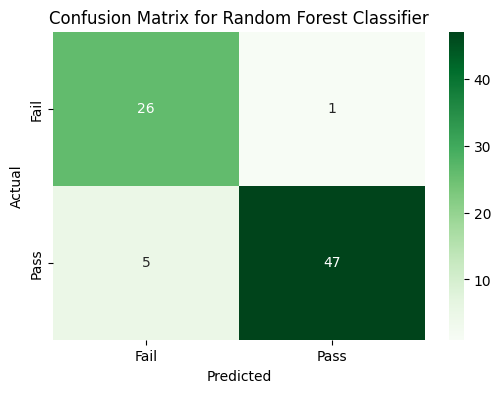

In [41]:
# Make predictions on the test set using the Random Forest model
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test_binary, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test_binary, y_pred_rf)
class_report_rf = classification_report(y_test_binary, y_pred_rf)

print(f"Random Forest Model Accuracy: {accuracy_rf:.2f}")
print("\nRandom Forest Confusion Matrix:")
print(conf_matrix_rf)
print("\nRandom Forest Classification Report:")
print(class_report_rf)

# Visualize the confusion matrix for Random Forest
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest Classifier')
plt.show()


--- Model Comparison ---
Logistic Regression Accuracy: 0.92
Random Forest Accuracy: 0.92

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.93      0.89        27
           1       0.96      0.92      0.94        52

    accuracy                           0.92        79
   macro avg       0.91      0.92      0.92        79
weighted avg       0.93      0.92      0.92        79

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.96      0.90        27
           1       0.98      0.90      0.94        52

    accuracy                           0.92        79
   macro avg       0.91      0.93      0.92        79
weighted avg       0.93      0.92      0.93        79



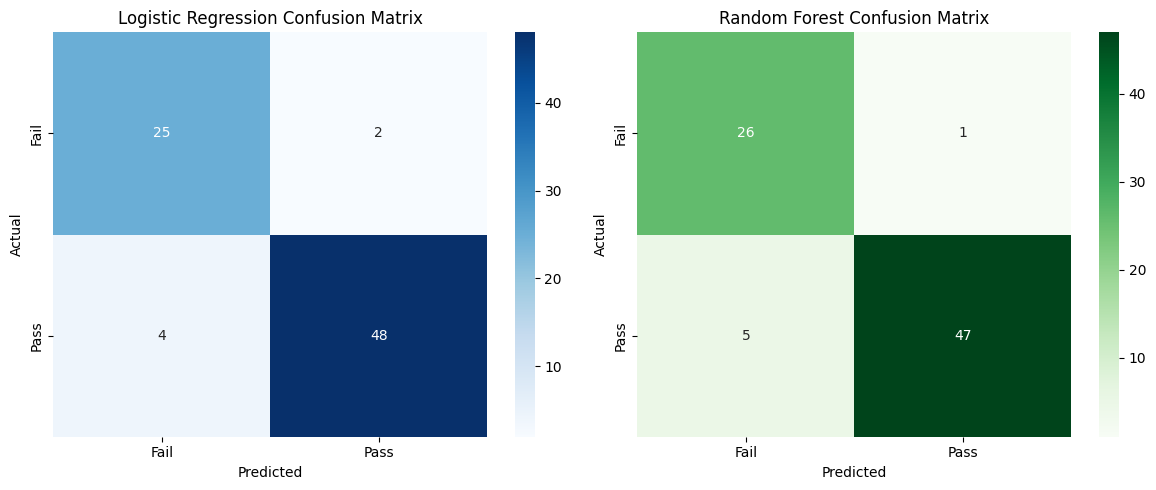

In [42]:
print("\n--- Model Comparison ---")
print("Logistic Regression Accuracy: {:.2f}".format(accuracy))
print("Random Forest Accuracy: {:.2f}\n".format(accuracy_rf))

print("Logistic Regression Classification Report:\n", class_report)
print("Random Forest Classification Report:\n", class_report_rf)

# Side-by-side comparison of Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Confusion Matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Logistic Regression Confusion Matrix')

# Random Forest Confusion Matrix
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'], ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Random Forest Confusion Matrix')

plt.tight_layout()
plt.show()


In [44]:
# Export the Logistic Regression model
logistic_model_filename = 'logistic_regression_model.joblib'
joblib.dump(logistic_model, logistic_model_filename)
print(f"Logistic Regression model exported to '{logistic_model_filename}'")

# Export the Random Forest model
random_forest_model_filename = 'random_forest_model.joblib'
joblib.dump(random_forest_model, random_forest_model_filename)
print(f"Random Forest model exported to '{random_forest_model_filename}'")

Logistic Regression model exported to 'logistic_regression_model.joblib'
Random Forest model exported to 'random_forest_model.joblib'


In [46]:
# Install Streamlit (if not already installed)
!pip install streamlit

import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load the trained Logistic Regression model
logistic_model = joblib.load('logistic_regression_model.joblib')

# Define the exact columns the model was trained on
# This list is crucial to ensure the input data matches the model's expectations
model_features = [
    'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
    'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
    'school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T',
    'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher',
    'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher',
    'reason_home', 'reason_other', 'reason_reputation', 'guardian_other',
    'guardian_mother', 'schoolsup_yes', 'famsup_yes', 'paid_yes',
    'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes',
    'romantic_yes'
]

# Define information for categorical features (original values before one-hot encoding)
# This helps create the correct Streamlit widgets and then correctly preprocess the input.
categorical_map = {
    'school': ['GP', 'MS'],
    'sex': ['F', 'M'],
    'address': ['U', 'R'],
    'famsize': ['GT3', 'LE3'],
    'Pstatus': ['A', 'T'],
    'Mjob': ['at_home', 'health', 'other', 'services', 'teacher'],
    'Fjob': ['at_home', 'health', 'other', 'services', 'teacher'],
    'reason': ['course', 'home', 'other', 'reputation'],
    'guardian': ['father', 'mother', 'other'],
    'schoolsup': ['yes', 'no'],
    'famsup': ['yes', 'no'],
    'paid': ['yes', 'no'],
    'activities': ['yes', 'no'],
    'nursery': ['yes', 'no'],
    'higher': ['yes', 'no'],
    'internet': ['yes', 'no'],
    'romantic': ['yes', 'no']
}

# Define information for numerical features (min/max/default for st.number_input)
numerical_info = {
    'age': {'min': 15, 'max': 22, 'default': 17},
    'Medu': {'min': 0, 'max': 4, 'default': 2},
    'Fedu': {'min': 0, 'max': 4, 'default': 2},
    'traveltime': {'min': 1, 'max': 4, 'default': 2},
    'studytime': {'min': 1, 'max': 4, 'default': 2},
    'failures': {'min': 0, 'max': 3, 'default': 0},
    'famrel': {'min': 1, 'max': 5, 'default': 4},
    'freetime': {'min': 1, 'max': 5, 'default': 3},
    'goout': {'min': 1, 'max': 5, 'default': 3},
    'Dalc': {'min': 1, 'max': 5, 'default': 1},
    'Walc': {'min': 1, 'max': 5, 'default': 2},
    'health': {'min': 1, 'max': 5, 'default': 3},
    'absences': {'min': 0, 'max': 93, 'default': 4}, # Max absences observed was 75, set a slightly higher max for input safety
    'G1': {'min': 0, 'max': 20, 'default': 10},
    'G2': {'min': 0, 'max': 20, 'default': 10},
}

def preprocess_input(input_data: dict, model_features: list) -> pd.DataFrame:
    """
    Preprocesses the raw input data from Streamlit to match the model's expected format.
    Applies one-hot encoding and reindexes the DataFrame.
    """
    input_df = pd.DataFrame([input_data])

    # Apply one-hot encoding to categorical columns, dropping the first category
    # This mimics the pd.get_dummies(df, columns=categorical_cols, drop_first=True) done during training.
    encoded_input_df = pd.get_dummies(input_df, columns=categorical_map.keys(), drop_first=True)

    # Reindex the DataFrame to match the model's training features exactly
    # Fill missing columns (categories not present in this single input row) with 0
    final_input = encoded_input_df.reindex(columns=model_features, fill_value=0)

    # Ensure all boolean columns are converted to the correct numerical type (0 or 1)
    for col in final_input.columns:
        if final_input[col].dtype == 'bool':
            final_input[col] = final_input[col].astype(int)

    return final_input

# --- Streamlit App Layout ---
st.set_page_config(page_title="Student Performance Predictor", layout="wide")
st.title("🎓 Student Performance Predictor")
st.markdown("This app predicts if a student will 'Pass' (G3 >= 10) or 'Fail' (G3 < 10) based on various factors.")

st.sidebar.header("Student Information")

# Collect user input
input_data = {}

# Numerical Inputs
st.sidebar.subheader("Grades and Demographics")
for feature, info in numerical_info.items():
    if feature not in ['G1', 'G2']: # G1 and G2 are input features for the model
        input_data[feature] = st.sidebar.number_input(
            f"{feature.replace('_', ' ').title()}",
            min_value=info['min'],
            max_value=info['max'],
            value=info['default']
        )

input_data['G1'] = st.sidebar.number_input(
    "First Period Grade (G1)",
    min_value=numerical_info['G1']['min'],
    max_value=numerical_info['G1']['max'],
    value=numerical_info['G1']['default']
)
input_data['G2'] = st.sidebar.number_input(
    "Second Period Grade (G2)",
    min_value=numerical_info['G2']['min'],
    max_value=numerical_info['G2']['max'],
    value=numerical_info['G2']['default']
)

st.sidebar.subheader("Categorical Factors")
for feature, options in categorical_map.items():
    input_data[feature] = st.sidebar.selectbox(
        f"{feature.replace('_', ' ').title()}",
        options=options,
        index=0 # Default to the first option
    )

# Prediction button
if st.button("Predict Final Grade Status"):
    # Preprocess the input data
    processed_input = preprocess_input(input_data, model_features)

    # Make prediction
    prediction = logistic_model.predict(processed_input)[0]
    prediction_proba = logistic_model.predict_proba(processed_input)[0]

    st.subheader("Prediction Result:")
    if prediction == 1:
        st.success(f"The student is predicted to **PASS** with a probability of {prediction_proba[1]:.2f}")
    else:
        st.error(f"The student is predicted to **FAIL** with a probability of {prediction_proba[0]:.2f}")

    st.write("--- Debug Information ---")
    st.write("Processed Input for Model:")
    st.dataframe(processed_input)
    st.write(f"Model Prediction Raw Output: {prediction}")
    st.write(f"Prediction Probabilities (Fail, Pass): {prediction_proba}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 74.3 MB/s eta 0:00:00


2026-05-24 09:03:20.823 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 09:03:20.825 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 09:03:20.923 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-24 09:03:20.924 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 09:03:20.924 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 09:03:20.927 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 09:03:20.928 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [47]:
streamlit_app_code = '''import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load the trained Logistic Regression model
logistic_model = joblib.load('logistic_regression_model.joblib')

# Define the exact columns the model was trained on
# This list is crucial to ensure the input data matches the model's expectations
model_features = [
    'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
    'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
    'school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T',
    'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher',
    'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher',
    'reason_home', 'reason_other', 'reason_reputation', 'guardian_other',
    'guardian_mother', 'schoolsup_yes', 'famsup_yes', 'paid_yes',
    'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes',
    'romantic_yes'
]

# Define information for categorical features (original values before one-hot encoding)
# This helps create the correct Streamlit widgets and then correctly preprocess the input.
categorical_map = {
    'school': ['GP', 'MS'],
    'sex': ['F', 'M'],
    'address': ['U', 'R'],
    'famsize': ['GT3', 'LE3'],
    'Pstatus': ['A', 'T'],
    'Mjob': ['at_home', 'health', 'other', 'services', 'teacher'],
    'Fjob': ['at_home', 'health', 'other', 'services', 'teacher'],
    'reason': ['course', 'home', 'other', 'reputation'],
    'guardian': ['father', 'mother', 'other'],
    'schoolsup': ['yes', 'no'],
    'famsup': ['yes', 'no'],
    'paid': ['yes', 'no'],
    'activities': ['yes', 'no'],
    'nursery': ['yes', 'no'],
    'higher': ['yes', 'no'],
    'internet': ['yes', 'no'],
    'romantic': ['yes', 'no']
}

# Define information for numerical features (min/max/default for st.number_input)
numerical_info = {
    'age': {'min': 15, 'max': 22, 'default': 17},
    'Medu': {'min': 0, 'max': 4, 'default': 2},
    'Fedu': {'min': 0, 'max': 4, 'default': 2},
    'traveltime': {'min': 1, 'max': 4, 'default': 2},
    'studytime': {'min': 1, 'max': 4, 'default': 2},
    'failures': {'min': 0, 'max': 3, 'default': 0},
    'famrel': {'min': 1, 'max': 5, 'default': 4},
    'freetime': {'min': 1, 'max': 5, 'default': 3},
    'goout': {'min': 1, 'max': 5, 'default': 3},
    'Dalc': {'min': 1, 'max': 5, 'default': 1},
    'Walc': {'min': 1, 'max': 5, 'default': 2},
    'health': {'min': 1, 'max': 5, 'default': 3},
    'absences': {'min': 0, 'max': 93, 'default': 4},
    'G1': {'min': 0, 'max': 20, 'default': 10},
    'G2': {'min': 0, 'max': 20, 'default': 10},
}

def preprocess_input(input_data: dict, model_features: list) -> pd.DataFrame:
    """
    Preprocesses the raw input data from Streamlit to match the model's expected format.
    Applies one-hot encoding and reindexes the DataFrame.
    """
    input_df = pd.DataFrame([input_data])

    # Apply one-hot encoding to categorical columns, dropping the first category
    # This mimics the pd.get_dummies(df, columns=categorical_cols, drop_first=True) done during training.
    encoded_input_df = pd.get_dummies(input_df, columns=categorical_map.keys(), drop_first=True)

    # Reindex the DataFrame to match the model's training features exactly
    # Fill missing columns (categories not present in this single input row) with 0
    final_input = encoded_input_df.reindex(columns=model_features, fill_value=0)

    # Ensure all boolean columns are converted to the correct numerical type (0 or 1)
    for col in final_input.columns:
        if final_input[col].dtype == 'bool':
            final_input[col] = final_input[col].astype(int)

    return final_input

# --- Streamlit App Layout ---
st.set_page_config(page_title="Student Performance Predictor", layout="wide")
st.title("🎓 Student Performance Predictor")
st.markdown("This app predicts if a student will 'Pass' (G3 >= 10) or 'Fail' (G3 < 10) based on various factors.")

st.sidebar.header("Student Information")

# Collect user input
input_data = {}

# Numerical Inputs
st.sidebar.subheader("Grades and Demographics")
for feature, info in numerical_info.items():
    if feature not in ['G1', 'G2']: # G1 and G2 are input features for the model
        input_data[feature] = st.sidebar.number_input(
            f"{feature.replace('_', ' ').title()}",
            min_value=info['min'],
            max_value=info['max'],
            value=info['default']
        )

input_data['G1'] = st.sidebar.number_input(
    "First Period Grade (G1)",
    min_value=numerical_info['G1']['min'],
    max_value=numerical_info['G1']['max'],
    value=numerical_info['G1']['default']
)
input_data['G2'] = st.sidebar.number_input(
    "Second Period Grade (G2)",
    min_value=numerical_info['G2']['min'],
    max_value=numerical_info['G2']['max'],
    value=numerical_info['G2']['default']
)

st.sidebar.subheader("Categorical Factors")
for feature, options in categorical_map.items():
    input_data[feature] = st.sidebar.selectbox(
        f"{feature.replace('_', ' ').title()}",
        options=options,
        index=0 # Default to the first option
    )

# Prediction button
if st.button("Predict Final Grade Status"):
    # Preprocess the input data
    processed_input = preprocess_input(input_data, model_features)

    # Make prediction
    prediction = logistic_model.predict(processed_input)[0]
    prediction_proba = logistic_model.predict_proba(processed_input)[0]

    st.subheader("Prediction Result:")
    if prediction == 1:
        st.success(f"The student is predicted to **PASS** with a probability of {prediction_proba[1]:.2f}")
    else:
        st.error(f"The student is predicted to **FAIL** with a probability of {prediction_proba[0]:.2f}")

    st.write("--- Debug Information ---")
    st.write("Processed Input for Model:")
    st.dataframe(processed_input)
    st.write(f"Model Prediction Raw Output: {prediction}")
    st.write(f"Prediction Probabilities (Fail, Pass): {prediction_proba}")'''

with open("app.py", "w") as f:
    f.write(streamlit_app_code)

print("Streamlit app code exported to app.py")

Streamlit app code exported to app.py


In [48]:
requirements_content = """
streamlit
pandas
joblib
numpy
"""

with open("requirements.txt", "w") as f:
    f.write(requirements_content)

print("requirements.txt created successfully.")

requirements.txt created successfully.


In [49]:
readme_content = """# Student Performance Prediction Project

This project aims to predict student performance based on various academic, demographic, and social factors using machine learning models. Specifically, it focuses on predicting whether a student will 'Pass' (final grade G3 >= 10) or 'Fail' (final grade G3 < 10) in a mathematics course.

## Project Workflow

The project follows a standard machine learning workflow:

1.  **Environment Setup & Data Loading:** Essential libraries are imported, and the dataset is loaded.
2.  **Data Quality Checks & Initial Exploration:** Basic checks for missing values and duplicate rows are performed.
3.  **Exploratory Data Analysis (EDA):** Key features are visualized to understand their distribution and relationship with the target variable.
4.  **Feature Engineering & Preprocessing:** Categorical variables are converted into numerical formats using one-hot encoding.
5.  **Feature Selection:** Correlations with the target variable `G3` are examined.
6.  **Data Splitting:** The dataset is divided into training and testing sets.
7.  **Model Training:** Logistic Regression and Random Forest Classifier models are trained.
8.  **Model Evaluation:** Models are assessed using accuracy, confusion matrix, and classification reports.
9.  **Model Export:** Trained models are saved for future use.
10. **Streamlit Application:** A user-friendly web application is developed to interact with the trained model.

## Dataset

The dataset used is `student-mat.csv`, which contains student grades and various attributes. It was obtained from KaggleHub.

-   **Source:** UCI Student Performance Dataset by Paulo Cortez
-   **Key Features:** `G1` (first period grade), `G2` (second period grade), `age`, `Medu` (mother's education), `Fedu` (father's education), `traveltime`, `studytime`, `failures`, `internet` access, etc.
-   **Target Variable:** `G3` (final grade), converted to a binary 'Pass' (G3 >= 10) / 'Fail' (G3 < 10) for classification.

## Key Steps and Findings

### 1. Data Loading and Initial Exploration
-   The `student-mat.csv` dataset was loaded into a Pandas DataFrame `df` using `delimiter=';'`.
-   Initial checks confirmed no missing values and no duplicate rows.
-   The dataset contains 395 entries and 33 columns.

### 2. Exploratory Data Analysis (EDA)
-   **Distribution of G3:** A histogram showed the distribution of final grades.
-   **Grades Correlation:** Strong positive correlations were observed between `G1`, `G2`, and `G3` (e.g., G2 and G3 correlation of 0.90).
-   **Impact of Factors on G3:** Box plots revealed insights, such as a negative relationship between previous failures and final grades.
-   **Overall Correlation:** A heatmap displayed correlations across all numerical features.

### 3. Feature Engineering
-   Categorical variables were transformed into numerical representations using **one-hot encoding** (`pd.get_dummies`), resulting in `df_encoded` with 42 features.

### 4. Feature Selection
-   Features highly correlated with `G3` were identified, including `G1`, `G2`, `Medu`, and `failures`.

### 5. Data Splitting
-   The `df_encoded` dataset was split into training (80%) and testing (20%) sets (`X_train`, `X_test`, `y_train`, `y_test`).

### 6. Model Training & Evaluation (Classification)
-   The continuous `G3` variable was converted to a binary target: 'Pass' (G3 >= 10) and 'Fail' (G3 < 10).
-   **Logistic Regression Model:**
    -   Accuracy: **0.92**
    -   A classification report and confusion matrix were generated.
-   **Random Forest Classifier Model:**
    -   Accuracy: **0.92**
    -   A classification report and confusion matrix were also generated.
-   Both models showed comparable performance, with slight differences in false positive/negative rates.

### 7. Model Export
-   Both the trained `LogisticRegression` model and `RandomForestClassifier` model were saved using `joblib` as `logistic_regression_model.joblib` and `random_forest_model.joblib`, respectively.

### 8. Streamlit Application
-   A Streamlit application (`app.py`) was developed to provide an interactive interface for predicting student performance using the trained Logistic Regression model.

## Project Files

-   `_T-bvTtKf35m.ipynb`: The Jupyter notebook containing the full analysis and code.
-   `student_data_cleaned.csv`: The cleaned and preprocessed dataset after one-hot encoding.
-   `preprocess_data.py`: A Python script encapsulating the data loading and one-hot encoding logic.
-   `logistic_regression_model.joblib`: The saved trained Logistic Regression model.
-   `random_forest_model.joblib`: The saved trained Random Forest Classifier model.
-   `app.py`: The Streamlit web application code.
-   `requirements.txt`: A list of Python dependencies required to run the project and the Streamlit app.

## How to Run the Streamlit Application

1.  **Ensure you have the necessary files:** Make sure `app.py`, `requirements.txt`, and `logistic_regression_model.joblib` are in the same directory.

2.  **Install dependencies:**
    ```bash
    pip install -r requirements.txt
    ```

3.  **Run the Streamlit app:**
    ```bash
    streamlit run app.py
    ```

    This command will launch the Streamlit application in your web browser. If running in a cloud environment like Google Colab, it will provide a public URL.

## Future Work

-   Hyperparameter tuning for both Logistic Regression and Random Forest models.
-   Exploring other classification algorithms (e.g., SVM, Gradient Boosting).
-   Further in-depth EDA on factors like 'absence impact on grades', 'family support', and 'parental education'.
-   Implementing a feature importance analysis for the Random Forest model.
-   Containerizing the Streamlit application using Docker.
"""

with open("README.md", "w") as f:
    f.write(readme_content)

print("README.md created successfully.")

README.md created successfully.
